In [3]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Torch Version: 2.11.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
#  DATA LOADING 

In [5]:
from torchvision import datasets
from torch.utils.data import random_split

In [6]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    root="../Data/plantvillage/color"
)

In [7]:
import os

print(os.listdir())

['Custom_CNN.ipynb', 'Data_Loading.ipynb', 'Evaluation.ipynb', 'Inference.ipynb', 'Training.ipynb']


In [8]:
import os

print(os.getcwd())

c:\Users\utyo1\OneDrive\Desktop\PLANT-DISEASE-DETECTION\Notebook


In [9]:
import os

print(os.listdir(".."))

['Data', 'Models', 'Notebook', 'Src']


In [10]:
print(os.listdir("../Data"))

['plantvillage']


In [11]:
print(os.listdir("../Data/plantvillage")[:5])

['color']


In [12]:
print("Total Images :", len(dataset))

print("Total Classes :", len(dataset.classes))

print(dataset.classes[:5])

print(dataset.class_to_idx)

Total Images : 54305
Total Classes : 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, '

In [13]:
print(type(dataset))
print(len(dataset))

<class 'torchvision.datasets.folder.ImageFolder'>
54305


In [14]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

In [15]:
dataset = datasets.ImageFolder(
    root="../Data/plantvillage/color",
    transform=transform
)

In [16]:
image, label = dataset[0]

print(type(image))
print(type(label))

print(image.shape)
print(label)

<class 'torch.Tensor'>
<class 'int'>
torch.Size([3, 256, 256])
0


In [17]:
from torchvision import transforms
from torchvision import datasets

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../Data/plantvillage/color",
    transform=transform
)

image, label = dataset[0]

print(type(image))
print(image.shape)
print(image.min(), image.max())
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
tensor(0.0118) tensor(0.8784)
0


In [18]:
# DATA LOADER

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(train_loader)

In [20]:
# data loader iterator helps to iterate through the data loader and get batches of images and labels.

In [21]:
batch = iter(train_loader)

images, labels = next(batch)# we use next() to get the next batch of images and labels from the iterator.

print(type(images))
print(type(labels))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [22]:
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [23]:
print(labels)

tensor([29, 24, 30, 35, 24, 34,  3, 28, 26, 26, 16, 35, 15, 35, 35,  4,  6, 25,
        26, 18, 15,  3, 25, 24, 10,  4, 35, 18, 29, 37,  9, 21])


In [24]:
print(dataset.classes[28])

Tomato___Bacterial_spot


In [25]:
# visualization of images and labels

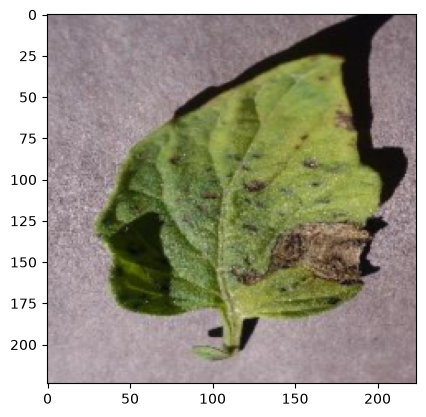

In [26]:
import matplotlib.pyplot as plt

image = images[0]

plt.imshow(image.permute(1,2,0))# it is used to change the order of dimensions of the image tensor from (C, H, W) to (H, W, C) so that it can be displayed using matplotlib.
plt.show()

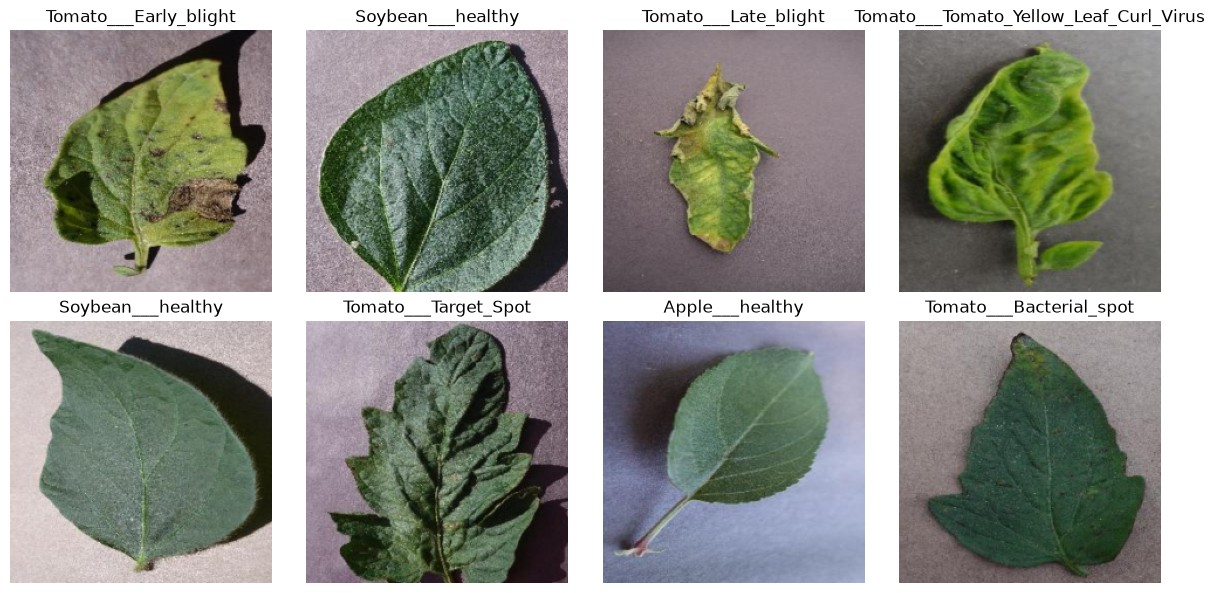

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flatten()): # enmumerate is used to get the index and the axis object for each subplot in the figure. axes.flatten() is used to flatten the 2D array of axes into a 1D array so that we can iterate through it easily.

    ax.imshow(images[i].permute(1,2,0))

    ax.set_title(dataset.classes[labels[i]])

    ax.axis("off")

plt.tight_layout()# it is used to automatically adjust the spacing between subplots in the figure so that they do not overlap with each other and are displayed properly.
plt.show()

In [30]:
# TRAIN TEST SPLIT

In [28]:
from torch.utils.data import random_split

In [29]:
dataset_size = len(dataset)

print(dataset_size)

54305


In [31]:
train_size = int(0.8 * dataset_size)

val_size = int(0.1 * dataset_size)

test_size = dataset_size - train_size - val_size

In [ ]:
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)
# random_split is used to split the dataset into train, validation and test datasets. It takes the dataset and a list of sizes for each split as input and returns three datasets.

In [35]:
print("Train :", len(train_dataset))

print("Validation :", len(val_dataset))

print("Test :", len(test_dataset))

Train : 43444
Validation : 5430
Test : 5431
